<a href="https://colab.research.google.com/github/Venky404/Google-Colab-Assignment/blob/main/Weather_App_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [6]:
# Load Dataset

df = pd.read_csv("weatherAUS.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [7]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [8]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 145460
Columns : 23


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [10]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [11]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Sunshine,69835,48.009762
Evaporation,62790,43.166506
Cloud3pm,59358,40.807095
Cloud9am,55888,38.421559
Pressure9am,15065,10.356799
Pressure3pm,15028,10.331363
WindDir9am,10566,7.263853
WindGustDir,10326,7.098859
WindGustSpeed,10263,7.055548
Humidity3pm,4507,3.098446


In [12]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [13]:
df.dtypes

,0
Date,object
Location,object
MinTemp,float64
MaxTemp,float64
Rainfall,float64
Evaporation,float64
Sunshine,float64
WindGustDir,object
WindGustSpeed,float64
WindDir9am,object


In [14]:
print(df["RainTomorrow"].value_counts())

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64


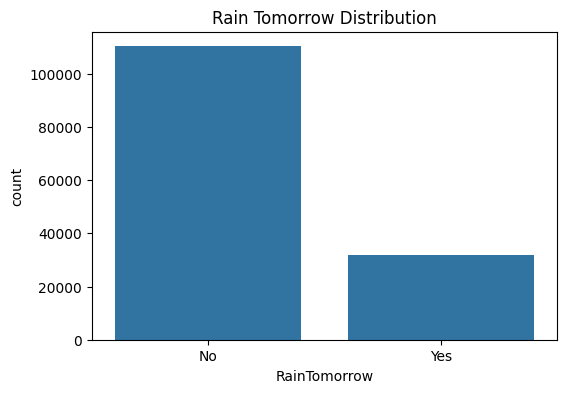

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x="RainTomorrow", data=df)

plt.title("Rain Tomorrow Distribution")
plt.show()

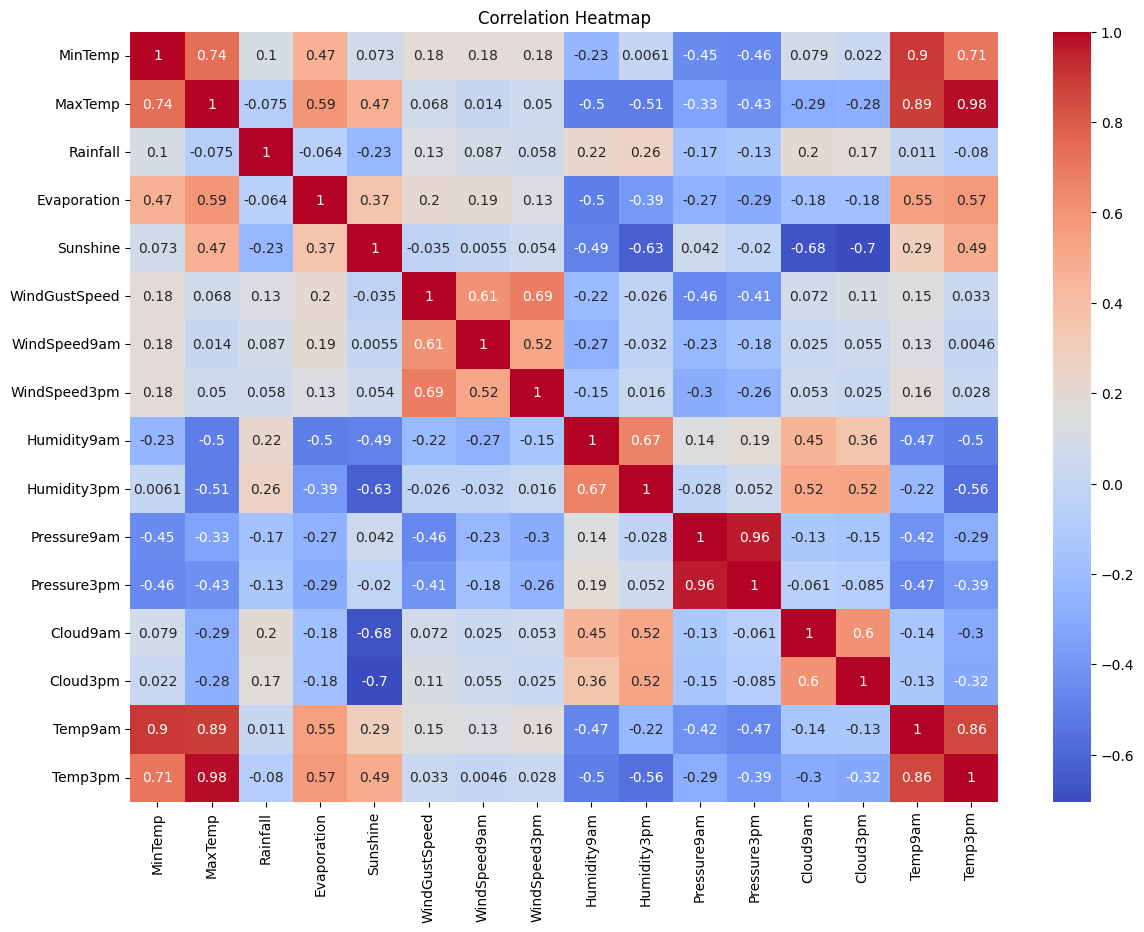

In [16]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    annot=True
)

plt.title("Correlation Heatmap")
plt.show()

In [17]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique()[:10])


Date
['2008-12-01' '2008-12-02' '2008-12-03' '2008-12-04' '2008-12-05'
 '2008-12-06' '2008-12-07' '2008-12-08' '2008-12-09' '2008-12-10']

Location
['Albury' 'BadgerysCreek' 'Cobar' 'CoffsHarbour' 'Moree' 'Newcastle'
 'NorahHead' 'NorfolkIsland' 'Penrith' 'Richmond']

MinTemp
[13.4  7.4 12.9  9.2 17.5 14.6 14.3  7.7  9.7 13.1]

MaxTemp
[22.9 25.1 25.7 28.  32.3 29.7 25.  26.7 31.9 30.1]

Rainfall
[ 0.6  0.   1.   0.2  1.4  2.2 15.6  3.6  nan 16.8]

Evaporation
[ nan 12.  14.8 12.6 10.8 11.4 11.2 13.   9.8 14.6]

Sunshine
[ nan 12.3 13.  13.3 10.6 12.2  8.4  0.  12.6 13.2]

WindGustDir
['W' 'WNW' 'WSW' 'NE' 'NNW' 'N' 'NNE' 'SW' nan 'ENE']

WindGustSpeed
[44. 46. 24. 41. 56. 50. 35. 80. 28. 30.]

WindDir9am
['W' 'NNW' 'SE' 'ENE' 'SW' 'SSE' 'S' 'NE' nan 'SSW']

WindDir3pm
['WNW' 'WSW' 'E' 'NW' 'W' 'SSE' 'ESE' 'ENE' 'NNW' 'SSW']

WindSpeed9am
[20.  4. 19. 11.  7.  6. 15. 17. 28. 24.]

WindSpeed3pm
[24. 22. 26.  9. 20. 17. 28. 11.  6. 13.]

Humidity9am
[71. 44. 38. 45. 82. 55. 49. 48. 42. 

In [18]:
# Remove Date column
df.drop("Date", axis=1, inplace=True)

print("Date column removed successfully.")

Date column removed successfully.


In [19]:
df.isnull().sum()

,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566
WindDir3pm,4228


In [20]:
# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print("Numerical missing values filled.")

Numerical missing values filled.


In [21]:
# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Categorical missing values filled.")

Categorical missing values filled.


In [22]:
df.isnull().sum()

,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustDir,0
WindGustSpeed,0
WindDir9am,0
WindDir3pm,0


In [23]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Categorical columns encoded successfully.")

Categorical columns encoded successfully.


In [24]:
print(df.dtypes)

Location           int64
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustDir        int64
WindGustSpeed    float64
WindDir9am         int64
WindDir3pm         int64
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
RainToday          int64
RainTomorrow       int64
dtype: object


In [25]:
X = df.drop("RainTomorrow", axis=1)
y = df["RainTomorrow"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (145460, 21)
Target Shape : (145460,)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed.")

Feature scaling completed.


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (116368, 21)
Testing Data : (29092, 21)


In [28]:
print("Object Columns Remaining:")
print(df.select_dtypes(include='object').columns)

print("\nMissing Values:")
print(df.isnull().sum().sum())

Object Columns Remaining:
Index([], dtype='object')

Missing Values:
0


In [29]:
# Create a smaller sample for SVM
sample_df = df.sample(n=20000, random_state=42)

print("Sample Shape:", sample_df.shape)

Sample Shape: (20000, 22)


In [30]:
X_sample = sample_df.drop("RainTomorrow", axis=1)
y_sample = sample_df["RainTomorrow"]

In [31]:
from sklearn.preprocessing import StandardScaler

sample_scaler = StandardScaler()

X_sample_scaled = sample_scaler.fit_transform(X_sample)

In [32]:
from sklearn.model_selection import train_test_split

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_sample_scaled,
    y_sample,
    test_size=0.2,
    random_state=42,
    stratify=y_sample
)

In [33]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [34]:
C_values = [1, 10]
kernels = ['linear', 'rbf']

best_accuracy = 0
best_model = None

for c in C_values:
    for kernel in kernels:

        model = SVC(C=c, kernel=kernel)

        model.fit(X_train_svm, y_train_svm)

        pred = model.predict(X_test_svm)

        acc = accuracy_score(y_test_svm, pred)

        print(f"C={c}, Kernel={kernel}, Accuracy={acc:.4f}")

        if acc > best_accuracy:
            best_accuracy = acc
            best_model = model

print("\nBest Accuracy:", best_accuracy)

C=1, Kernel=linear, Accuracy=0.8423
C=1, Kernel=rbf, Accuracy=0.8423
C=10, Kernel=linear, Accuracy=0.8423
C=10, Kernel=rbf, Accuracy=0.8370

Best Accuracy: 0.84225


In [35]:
param_grid = {
    'C': [1, 10],
    'kernel': ['linear', 'rbf']
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train_svm, y_train_svm)

GridSearchCV(cv=3, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [1, 10], 'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [36]:
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

grid_pred = grid.predict(X_test_svm)

print("Test Accuracy:", accuracy_score(y_test_svm, grid_pred))

Best Parameters: {'C': 1, 'kernel': 'rbf'}
Best CV Accuracy: 0.8448130651585296
Test Accuracy: 0.84225


In [37]:
param_dist = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

random = RandomizedSearchCV(
    estimator=SVC(),
    param_distributions=param_dist,
    n_iter=4,
    cv=3,
    random_state=42,
    scoring='accuracy',
    n_jobs=-1
)

random.fit(X_train_svm, y_train_svm)

RandomizedSearchCV(cv=3, estimator=SVC(), n_iter=4, n_jobs=-1,
                   param_distributions={'C': [0.1, 1, 10],
                                        'kernel': ['linear', 'rbf']},
                   random_state=42, scoring='accuracy')

In [38]:
print("Best Parameters:", random.best_params_)
print("Best CV Accuracy:", random.best_score_)

random_pred = random.predict(X_test_svm)

print("Test Accuracy:", accuracy_score(y_test_svm, random_pred))

Best Parameters: {'kernel': 'rbf', 'C': 10}
Best CV Accuracy: 0.8416878346797687
Test Accuracy: 0.837


In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

In [40]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_acc)
print(classification_report(y_test, rf_pred))

Random Forest Accuracy : 0.8612677024611577
              precision    recall  f1-score   support

           0       0.88      0.96      0.92     22717
           1       0.77      0.52      0.62      6375

    accuracy                           0.86     29092
   macro avg       0.83      0.74      0.77     29092
weighted avg       0.85      0.86      0.85     29092



In [41]:
ada = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)

ada_acc = accuracy_score(y_test, ada_pred)

print("AdaBoost Accuracy :", ada_acc)
print(classification_report(y_test, ada_pred))

AdaBoost Accuracy : 0.8440808469682387
              precision    recall  f1-score   support

           0       0.87      0.94      0.90     22717
           1       0.71      0.49      0.58      6375

    accuracy                           0.84     29092
   macro avg       0.79      0.72      0.74     29092
weighted avg       0.83      0.84      0.83     29092



In [42]:
gb = GradientBoostingClassifier(
    n_estimators=100,
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

gb_acc = accuracy_score(y_test, gb_pred)

print("Gradient Boosting Accuracy :", gb_acc)
print(classification_report(y_test, gb_pred))

Gradient Boosting Accuracy : 0.8528805169806132
              precision    recall  f1-score   support

           0       0.87      0.95      0.91     22717
           1       0.75      0.50      0.60      6375

    accuracy                           0.85     29092
   macro avg       0.81      0.73      0.75     29092
weighted avg       0.84      0.85      0.84     29092



In [43]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy :", xgb_acc)
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy : 0.8599271277327101
              precision    recall  f1-score   support

           0       0.88      0.95      0.91     22717
           1       0.74      0.55      0.63      6375

    accuracy                           0.86     29092
   macro avg       0.81      0.75      0.77     29092
weighted avg       0.85      0.86      0.85     29092



In [44]:
print("Random Forest Accuracy      :", rf_acc)
print("AdaBoost Accuracy           :", ada_acc)
print("Gradient Boosting Accuracy  :", gb_acc)
print("XGBoost Accuracy            :", xgb_acc)

Random Forest Accuracy      : 0.8612677024611577
AdaBoost Accuracy           : 0.8440808469682387
Gradient Boosting Accuracy  : 0.8528805169806132
XGBoost Accuracy            : 0.8599271277327101


In [45]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Accuracy": [
        rf_acc,
        ada_acc,
        gb_acc,
        xgb_acc
    ]
})

results

,Model,Accuracy
0,Random Forest,0.861268
1,AdaBoost,0.844081
2,Gradient Boosting,0.852881
3,XGBoost,0.859927


In [46]:
results = results.sort_values(by="Accuracy", ascending=False)

results

,Model,Accuracy
0,Random Forest,0.861268
3,XGBoost,0.859927
2,Gradient Boosting,0.852881
1,AdaBoost,0.844081


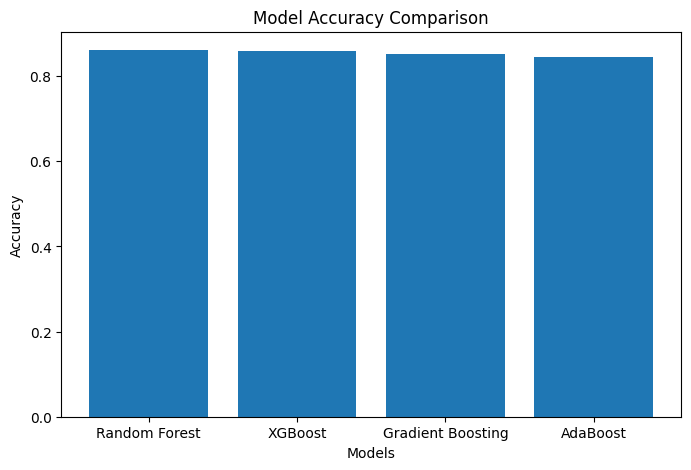

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

In [48]:
best_model_name = results.iloc[0]["Model"]

print("Best Model :", best_model_name)
print("Best Accuracy :", results.iloc[0]["Accuracy"])

Best Model : Random Forest
Best Accuracy : 0.8612677024611577


In [49]:
import joblib

if best_model_name == "Random Forest":
    best_model = rf

elif best_model_name == "AdaBoost":
    best_model = ada

elif best_model_name == "Gradient Boosting":
    best_model = gb

else:
    best_model = xgb

joblib.dump(best_model, "best_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [50]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler Saved Successfully!")

Scaler Saved Successfully!


In [51]:
joblib.dump(list(X.columns), "columns.pkl")

print("Columns Saved Successfully!")

Columns Saved Successfully!


In [52]:
loaded_model = joblib.load("best_model.pkl")

prediction = loaded_model.predict(X_test[:5])

print("Predictions:")
print(prediction)

Predictions:
[0 0 0 0 0]


In [53]:
from google.colab import files

files.download("best_model.pkl")
files.download("scaler.pkl")
files.download("columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
print(list(X.columns))

['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday']
